In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import sqlite3

DB_PATH = Path("epstein.db").resolve()
conn = sqlite3.connect(DB_PATH, timeout=30.0)

In [27]:
# Example rows using normalized schema (no pandas)
cur = conn.execute(
    """
    SELECT
      f.id,
      f.flight_date,
      ao.name AS origin,
      ad.name AS destination,
      wc.code AS departure_weather
    FROM flights f
    LEFT JOIN airports ao ON ao.id = f.origin_airport_id
    LEFT JOIN airports ad ON ad.id = f.destination_airport_id
    LEFT JOIN weather_conditions wc ON wc.id = f.departure_weather_id
    WHERE wc.code IN ('sunny', 'rainy')
    LIMIT 15
    """
)
cols = [d[0] for d in cur.description]
rows = cur.fetchall()
print(cols)
for row in rows:
    print(row)

['id', 'flight_date', 'origin', 'destination', 'departure_weather']
('f-1708', '2019-07-06', 'LFBG Airport', 'Teterboro Airport, NJ', 'sunny')
('f-1706', '2019-06-26', 'Middle Georgia Regional Airport', 'GYH Airport', 'sunny')
('f-1705', '2019-06-26', 'GYH Airport', 'RYY Airport', 'sunny')
('f-1704', '2019-06-19', 'Palm Beach International Airport', 'MCN Airport', 'rainy')
('f-1703', '2019-06-14', 'Teterboro Airport', 'Le Bourget, Paris, France', 'rainy')
('f-1702', '2019-06-14', 'Middle Georgia Regional Airport', 'Palm Beach International, FL', 'sunny')
('f-1701', '2019-06-11', 'Cyril E. King Airport', 'Teterboro Airport, NJ', 'rainy')
('f-1700', '2019-06-05', 'Middle Georgia Regional Airport', 'MCN Airport', 'rainy')
('f-1699', '2019-06-03', 'Teterboro Airport', 'TIST Airport', 'sunny')
('f-1698', '2019-06-01', 'Palm Beach International Airport', 'Teterboro Airport, NJ', 'rainy')
('f-1697', '2019-05-28', 'Tucson International Airport', 'Palm Beach International, FL', 'sunny')
('f-169

In [28]:
# Percentages per weather label for one destination
destination_name = "Cyril E King Airport"

cur = conn.execute(
  """
  SELECT
    COALESCE(wc.code, 'unknown_day') AS weather,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
  FROM flights f
  LEFT JOIN airports ad ON ad.id = f.destination_airport_id
  LEFT JOIN weather_conditions wc ON wc.id = f.departure_weather_id
  WHERE LOWER(TRIM(ad.name)) = LOWER(TRIM(?))
  GROUP BY wc.code
  ORDER BY percentage DESC
  """,
  (destination_name,)
)
dep_weather_rows = cur.fetchall()
dep_weather_labels = [r[0] for r in dep_weather_rows]
dep_percentages = [float(r[1]) for r in dep_weather_rows]

cur = conn.execute(
  """
  SELECT
    COALESCE(wc.code, 'unknown_day') AS weather,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
  FROM flights f
  LEFT JOIN airports ad ON ad.id = f.destination_airport_id
  LEFT JOIN weather_conditions wc ON wc.id = f.arrival_weather_id
  WHERE LOWER(TRIM(ad.name)) = LOWER(TRIM(?))
  GROUP BY wc.code
  ORDER BY percentage DESC
  """,
  (destination_name,)
)
arr_weather_rows = cur.fetchall()
arr_weather_labels = [r[0] for r in arr_weather_rows]
arr_percentages = [float(r[1]) for r in arr_weather_rows]

print("Departure:", list(zip(dep_weather_labels, dep_percentages)))
print("Arrival:", list(zip(arr_weather_labels, arr_percentages)))

[('rainy', 52.31), ('sunny', 47.69)]

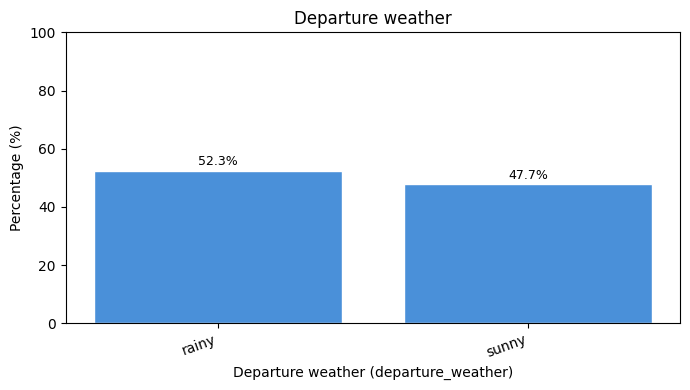

In [ ]:
# Graph 1: departure weather percentages
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dep_weather_labels, dep_percentages, color="#4a90d9", edgecolor="white")

ax.set_ylim(0, 100)
ax.set_xlabel("Departure weather")
ax.set_ylabel("Percentage (%)")
ax.set_title(f"Departure weather - {destination_name}")

for bar, p in zip(bars, dep_percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Graph 2: arrival weather percentages
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(arr_weather_labels, arr_percentages, color="#f39c12", edgecolor="white")

ax.set_ylim(0, 100)
ax.set_xlabel("Arrival weather")
ax.set_ylabel("Percentage (%)")
ax.set_title(f"Arrival weather - {destination_name}")

for bar, p in zip(bars, arr_percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{p:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Connection closed.


In [ ]:
conn.close()
print("Connection closed.")